# Deliverable 1

### Task 1

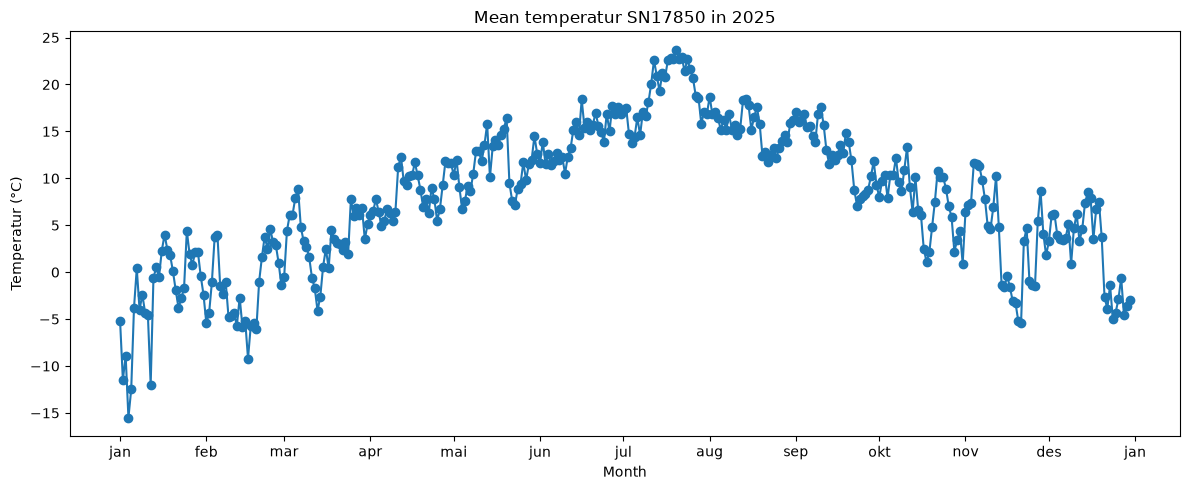

In [31]:
import locale
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import requests


def load_frost_key(path="../key_frost.py"):
    """Load API client ID from lokal file."""
    sys.path.append("..")
    with open(path, "r", encoding="utf-8") as file:
        return file.read().strip()


def get_frost_data(client_id):
    """Connctin to frost server and get the mean temperatur for 2025."""
    endpoint = "https://frost.met.no/observations/v0.jsonld"
    parameters = {
        "sources": "SN17850",
        "elements": "mean(air_temperature P1D)",
        "referencetime": "2025-01-01/2025-12-31",
    }

    response = requests.get(
        endpoint,
        params=parameters,
        auth=(client_id, "")
    )
    response.raise_for_status()
    return response.json()["data"]


def get_the_rigth_format(data):
    """Change dates and temperatures from Frost API response."""
    dates = []
    temps = []

    for entry in data:
        date = entry["referenceTime"][:10]  # YYYY-MM-DD
        temp = entry["observations"][0]["value"]
        dates.append(date)
        temps.append(temp)

    return dates, temps


def plot_temperature(dates, temps):
    """Plot temperature series with Norwegian month labels."""
    plt.figure(figsize=(12, 5))
    plt.plot(dates, temps, marker="o")

    locale.setlocale(locale.LC_TIME, "nb_NO.UTF-8")

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    plt.xticks(rotation=0)
    plt.xlabel("Month")
    plt.ylabel("Temperatur (°C)")
    plt.title("Mean temperatur SN17850 in 2025")
    plt.tight_layout()
    plt.show()


def main():
    client_id = load_frost_key()
    data = get_frost_data(client_id)
    dates, temps = get_the_rigth_format(data)
    plot_temperature(dates, temps)

if __name__ == "__main__":
    main()


### Task 2

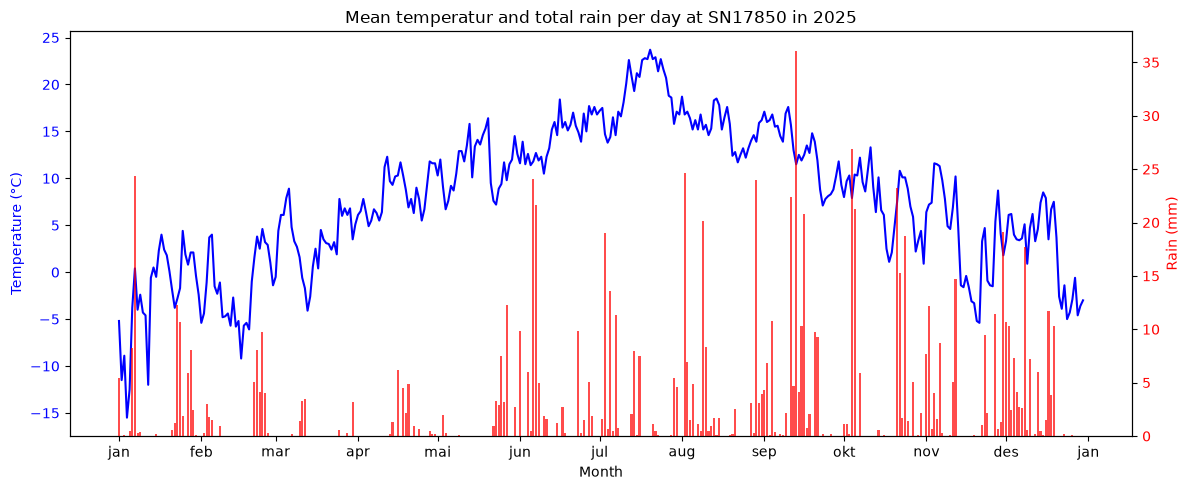

In [32]:
def get_frost_data_rain(client_id):
    """Connctin to frost server and get the precipitation for 2025."""
    endpoint = "https://frost.met.no/observations/v0.jsonld"
    parameters = {
        "sources": "SN17850",
        "elements": "sum(precipitation_amount P1D)",
        "referencetime": "2025-01-01/2025-12-31",
    }

    response = requests.get(
        endpoint,
        params=parameters,
        auth=(client_id, "")
    )
    response.raise_for_status()
    return response.json()["data"]

def get_the_rigth_format_rain(data):
    """Change rain from Frost API response."""
    rain = []

    for entry in data:
        rains = entry["observations"][0]["value"]
        rain.append(rains)

    return rain

def plot_temperature_rain(dates, temps, rain):
    """Plot rain series with Norwegian month labels."""
    
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # plott in the temperature
    ax1.plot(dates, temps, color="blue", label="Temperature (°C)")
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Temperature (°C)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # plott in the rain
    ax2 = ax1.twinx()

    ax2.bar(dates, rain, color="red", alpha=0.7, label="Rain (mm)")
    ax2.set_ylabel("Rain (mm)", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

    
    locale.setlocale(locale.LC_TIME, "nb_NO.UTF-8")
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    

    plt.xticks(rotation=0)
    plt.title("Mean temperatur and total rain per day at SN17850 in 2025")
    fig.tight_layout()
    plt.show()

def main():
    client_id = load_frost_key()
    data = get_frost_data(client_id)
    rdata = get_frost_data_rain(client_id)
    dates, temps = get_the_rigth_format(data)
    rain = get_the_rigth_format_rain(rdata)
    plot_temperature_rain(dates, temps, rain)

if __name__ == "__main__":
    main()



### Task 3

### Task 4

### Task 5